## Reconstructing galaxy velocties

The linearized continuity equation predicts the velocity field relatively well as a first order approximation, as it uses information of the whole density field. However, this model cannot properly predict the correct amplitude in high density region,which can be modelled by my skew-t model. In this notebook, we combine both models and test whether this hybrid model can give outperform both individual models.

In [1]:
import numpy as np
from matplotlib import pyplot as plt
import my_functions as mf
from scipy.optimize import minimize
from importlib import reload
from scipy.optimize import curve_fit
import swiftsimio
reload(mf)

<module 'my_functions' from '/data2/quinten/MRP/hybrid_model/my_functions.py'>

In [2]:
def reconstruct_velocities(simulation, velocity_space=False):
    # Solves the linearized continuity equation by going to fourier space
    if velocity_space:
        delta_g = simulation.delta_g_z
    else:
        delta_g = simulation.delta_g
    f, aH = simulation.cosmology['Om0']**.55, simulation.cosmology_raw['H [internal units]']

    k_i = 2 * np.pi * np.fft.fftfreq(simulation.bins, simulation.boxsize / simulation.bins)
    kx, ky, kz = np.meshgrid(k_i, k_i, k_i)
    k2 = kx**2 + ky**2 + kz**2

    delta_g_k = np.fft.fftn(delta_g)
    v_k = f * aH * delta_g_k * 1j * kx / k2
    v_k[k2 == 0] = 0

    reconstructed_cube = np.real(np.fft.ifftn(v_k))
    return reconstructed_cube

In [3]:
def calc_correlation(array1, array2):
    covariance_matrix = np.cov(array1, array2)
    correlation = covariance_matrix[0, 1] / np.prod(np.diagonal(covariance_matrix))**.5
    return correlation

In [4]:
def rms_difference(array1, array2):
    return np.mean((array1 - array2)**2)**.5

In [5]:
def reconstruction_rms(simulation, v_true, v_rec):
    n_g = simulation.number_density
    n_g = n_g[n_g > 0]
    return np.asarray([rms_difference(v_true[n == n_g], v_rec[n == n_g]) for n in range(int(np.max(n_g))+1)])

In [6]:
def reconstruct_all_velocities(simulation, model_t9):
    v_reconstr_cube = reconstruct_velocities(simulation)
    
    mask = ~np.isnan(simulation.voxel_velocity[0])
    v_lin = np.abs(v_reconstr_cube[mask])
    v_true = simulation.voxel_velocity[1][mask]
    # v_lin = scale_distribution(v_true, v_lin_raw)

    skew_t_parms = mf.t9_to_skew_t_params(np.arange(np.max(simulation.number_density)+1), model_t9)
    skew_t_velocities = mf.skew_t_mean(*skew_t_parms)
    v_t9 = skew_t_velocities[simulation.number_density[mask].astype(np.int64)]

    return v_lin, v_t9, v_true, simulation.number_density[mask]

In [7]:
def plot_mean_velocity_vs_n_g(ax, v_rec, n_g, **kwargs):
    n_gs = np.arange(np.max(n_g)+1)
    v_mean = [np.mean(v_rec[n_g == n]) for n in n_gs]

    ax.plot(n_gs, v_mean, **kwargs)

In [8]:
def plot_correlation_vs_n_g(ax, v_rec, v_true, n_g, **kwargs):
    n_gs = np.arange(np.max(n_g)+1)
    correlation = [calc_correlation(v_rec[n_g == n], v_true[n_g == n]) for n in n_gs]

    ax.scatter(n_gs, correlation, **kwargs)

In [9]:
def plot_rms_difference_vs_n_g(ax, v_rec, v_true, n_g, **kwargs):
    n_gs = np.arange(np.max(n_g)+1)
    rms = [rms_difference(v_rec[n_g == n], v_true[n_g == n]) for n in n_gs]

    ax.plot(n_gs, rms, **kwargs)

In [10]:
def plot_rms_difference_with_mean(ax, v_true, n_g, **kwargs):
    n_gs = np.arange(np.max(n_g)+1)
    rms = [rms_difference(np.mean(v_true[n_g == n]), v_true[n_g == n]) for n in n_gs]

    ax.plot(n_gs, rms, **kwargs)

In [11]:
sim = mf.load_simulation('L1m9_dmo_fiducial', '0077', '0+', 100)

In [12]:
skew_t9 = mf.load_model_t9(sim.simulation, sim.snapshot, sim.mass_tag, sim.bins, 10)
v_lin, v_t9, v_true, n_g = reconstruct_all_velocities(sim, skew_t9)

/var/tmp/zegveld/ipykernel_265891/2544234627.py:14: RuntimeWarning: invalid value encountered in divide
  v_k = f * aH * delta_g_k * 1j * kx / k2


Note that the linearized continuity equation predicts sign, where my skew-t model does not. This is not a problem, as kSZ observations measure the product of electron density and bulk motion. Since electron density cannot be negative, the measurement always contains the sign of the velocity, so we directly take this from the observations. For this reason, we exclusively work with positive velocities.

After reconstructing the velocities using linear theory, we create a hybrid 'nonlinear' model. We make the following assumptions. The linearized continuity equation correctly models deviations of the mean expected velocity given the galaxy overdensity in a voxel, but does not correctly predict the mean expected velocity itself. The skew-t model perfectly predicts the mean expected velocity in a voxel, but does not measure deviations between voxels with the same number density. Taking the velocities from linear theory and simply shifting the mean of all voxels with the same number density to the velocity predicted by the skew-t model then predicts both the amplitude and its deviations.

In [13]:
v_nonlin = v_lin.copy()
for n in range(int(np.max(n_g))+1):
    if np.sum(n_g == n) > 0:
        skew_t_params = mf.t9_to_skew_t_params(n, skew_t9)
        v_nonlin[n_g == n] += mf.skew_t_mean(*skew_t_params) - np.mean(v_lin[n_g == n])

/data2/quinten/.venv4/lib64/python3.12/site-packages/numpy/_core/fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/data2/quinten/.venv4/lib64/python3.12/site-packages/numpy/_core/_methods.py:145: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/data2/quinten/.venv4/lib64/python3.12/site-packages/numpy/lib/_function_base_impl.py:552: RuntimeWarning: Mean of empty slice.
  avg = a.mean(axis, **keepdims_kw)
/data2/quinten/.venv4/lib64/python3.12/site-packages/numpy/_core/_methods.py:137: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(
/var/tmp/zegveld/ipykernel_265891/3027487000.py:2: RuntimeWarning: Degrees of freedom <= 0 for slice
  covariance_matrix = np.cov(array1, array2)
/data2/quinten/.venv4/lib64/python3.12/site-packages/numpy/lib/_function_base_impl.py:2894: RuntimeWarning: divide by zero encountered in divide
  c *= np.true_divide(1, fact)
/dat

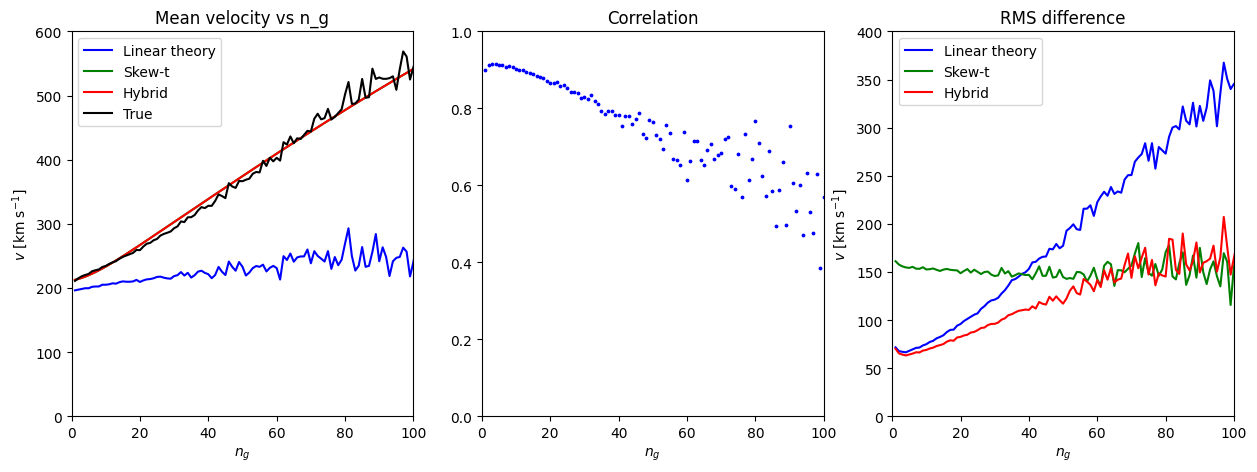

In [14]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=[15,5])

xlim=[0, 100]

plot_mean_velocity_vs_n_g(ax1, v_lin, n_g, c='b', label='Linear theory')
plot_mean_velocity_vs_n_g(ax1, v_t9, n_g, c='g', label='Skew-t')
plot_mean_velocity_vs_n_g(ax1, v_nonlin, n_g, c='r', label='Hybrid')
plot_mean_velocity_vs_n_g(ax1, v_true, n_g, c='black', label='True')
ax1.set(
    title='Mean velocity vs n_g',
    xlim=xlim,
    ylim=[0, 600],
    xlabel='$n_g$',
    ylabel='$v$ [km s$^{-1}$]',
)

ax1.legend()

plot_correlation_vs_n_g(ax2, v_lin, v_true, n_g, c='b', label='Correlation', s=3)
# plot_correlation_vs_n_g(ax2, v_t9, v_true, n_g, c='r', label='Correlation', linestyle='-.')
ax2.set(xlim=xlim, ylim=[0, 1], xlabel='$n_g$', title='Correlation')

plot_rms_difference_vs_n_g(ax3, v_lin, v_true, n_g, c='b', label='Linear theory')
plot_rms_difference_vs_n_g(ax3, v_t9, v_true, n_g, c='g', label='Skew-t')
plot_rms_difference_vs_n_g(ax3, v_nonlin, v_true, n_g, c='r', label='Hybrid')
# plot_rms_difference_with_mean(ax3, v_true, n_g, c='black', label='Predict mean')
ax3.set(xlim=xlim, ylim=[0, 400], xlabel='$n_g$', ylabel='$v$ [km s$^{-1}$]', title='RMS difference')

ax3.legend()
plt.show()

The first panel shows the mean velocity in each number density bin for different velocity reconstruction mechanisms. Linear theory underpredicts the mean velocity, which increases substantially with numer density. The skew-t model and hybrid model have identical means and nicely follow the true velocities.

The second panel shows the correlation coefficient between linear theory and true velocities. The correlation drops with increasing number density, indicating that the deviations of the mean are also modelled more poorly with increasing number density, not just the amplitude.

The third panel shows the RMS velocity difference between true and reconstructed velocities. The hybrid model clearly performs better than both individual models, except at very high number density.

To do
1. Test model for different cosmologies
   - Model maken voor alle cosmologieën en vergelijken
   - Model maken voor 1 cosmologie en testen op andere cosmologieën
2. Include $d^2\delta_g/dx^2$ in model
3. Go to redshift space
4. Test the effect of using non-periodic volumes (include only a part of the box)